# Exploratory Data Analysis (EDA) - HOPE-EXP

Este notebook realiza un análisis exploratorio detallado del dataset HOPE-EXP utilizando las utilidades definidas en el módulo `shared`.

In [1]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Añadir el directorio raíz al path para importar el módulo src.shared
ROOT_DIR = Path.cwd()
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

from src.shared.dataset import load_posts, convert_posts_to_df
from src.shared.eda import summarize_posts, get_ngrams

# Configuración de visualización
%matplotlib inline
sns.set_theme(style="whitegrid")

## 1. Carga de Datos
Cargamos el dataset de entrenamiento y lo convertimos a un DataFrame de Pandas para facilitar la manipulación.

In [2]:
DATA_PATH = "HopeEXP_Train.jsonl"
posts = load_posts(DATA_PATH)

# Convertir a DataFrame base
df = convert_posts_to_df(posts)
# Quitar span_annotations ya que tenemos columnas planas para Task C (span_texts) y Task D (outcome_stances, actors)
df = df.drop(columns=['span_annotations'])
display(df.head())

import spacy

# Carga de modelos optimizada
nlp_en = spacy.load("en_core_web_sm")
nlp_es = spacy.load("es_core_news_sm")

for nlp in [nlp_en, nlp_es]:
    if "sentencizer" not in nlp.pipe_names:
        nlp.add_pipe("sentencizer")
    nlp.select_pipes(enable=["sentencizer"])

def get_metrics(df):
    df = df.copy()
    for lang in df['lang'].unique():
        mask = df['lang'] == lang
        texts = df.loc[mask, 'source_text']
        nlp = nlp_es if lang == 'ES' else nlp_en
        
        lang_stats = []
        for doc in nlp.pipe(texts, batch_size=100):
            words = [t.text for t in doc if not t.is_punct and not t.is_space]
            sentences = list(doc.sents)
            num_w = len(words)
            num_s = len(sentences)
            avg_s = sum(len([t for t in s if not t.is_punct and not t.is_space]) for s in sentences) / num_s if num_s > 0 else 0.0
            lang_stats.append([num_w, len(doc.text), max([len(w) for w in words]) if words else 0, num_s, avg_s])
        
        df.loc[mask, ['num_words', 'num_chars', 'max_word_len', 'num_sentences', 'avg_sentence_len']] = lang_stats
    return df

df_metrics = get_metrics(df)
df_metrics.head()

,row_id,lang,title,selftext,source_text,primary_label,trigger_emotions,span_texts,outcome_stances,actors,num_spans
0,4850,EN,Parenting while drowning: How do I keep my kid...,I'm exhausted. Completely spent. I've got two ...,Parenting while drowning: How do I keep my kid...,General Hope,[sadness],[I just hope things will somehow improve witho...,[Desired],[World/System],1
1,4933,ES,Cómo es el plan de estudios y la duración de l...,Not Hope,Cómo es el plan de estudios y la duración de l...,Not Hope,[Nuetral/unclear],[],[],[],0
2,6381,EN,The Silicon Valley Dream That Keeps Crashing,So here's my tech career saga. I spent three y...,The Silicon Valley Dream That Keeps Crashing\n...,Sarcastic Hope,"[sadness, anger]",[And the worst part? I'm sure everything will ...,[Desired],[Self],1
3,4311,ES,Avance en mi tesis: superando la ansiedad inicial,Después de semanas paralizado por el miedo a n...,Avance en mi tesis: superando la ansiedad inic...,General Hope,"[fear, sadness, joy]",[siento que las cosas van mejorando],[Desired],[World/System],1
4,3047,ES,Quizá el cáncer desaparezca si dejo de pensar ...,"Dicen que la mente es poderosa, así que supong...",Quizá el cáncer desaparezca si dejo de pensar ...,Unrealistic Hope,"[fear, sadness, anger]",[supongo que si simplemente ignoro mi diagnóst...,[Desired],[World/System],1


,row_id,lang,title,selftext,source_text,primary_label,trigger_emotions,span_texts,outcome_stances,actors,num_spans,num_words,num_chars,max_word_len,num_sentences,avg_sentence_len
0,4850,EN,Parenting while drowning: How do I keep my kid...,I'm exhausted. Completely spent. I've got two ...,Parenting while drowning: How do I keep my kid...,General Hope,[sadness],[I just hope things will somehow improve witho...,[Desired],[World/System],1,207.0,1090.0,14.0,18.0,11.500000
1,4933,ES,Cómo es el plan de estudios y la duración de l...,Not Hope,Cómo es el plan de estudios y la duración de l...,Not Hope,[Nuetral/unclear],[],[],[],0,21.0,120.0,14.0,2.0,10.500000
2,6381,EN,The Silicon Valley Dream That Keeps Crashing,So here's my tech career saga. I spent three y...,The Silicon Valley Dream That Keeps Crashing\n...,Sarcastic Hope,"[sadness, anger]",[And the worst part? I'm sure everything will ...,[Desired],[Self],1,235.0,1336.0,11.0,14.0,16.785714
3,4311,ES,Avance en mi tesis: superando la ansiedad inicial,Después de semanas paralizado por el miedo a n...,Avance en mi tesis: superando la ansiedad inic...,General Hope,"[fear, sadness, joy]",[siento que las cosas van mejorando],[Desired],[World/System],1,92.0,560.0,15.0,4.0,23.000000
4,3047,ES,Quizá el cáncer desaparezca si dejo de pensar ...,"Dicen que la mente es poderosa, así que supong...",Quizá el cáncer desaparezca si dejo de pensar ...,Unrealistic Hope,"[fear, sadness, anger]",[supongo que si simplemente ignoro mi diagnóst...,[Desired],[World/System],1,213.0,1345.0,15.0,14.0,15.214286


## 2. Resumen Estadístico
Obtenemos las estadísticas generales utilizando la función `summarize_posts`.

In [3]:
summary = summarize_posts(posts)

print(f"Total de posts: {summary['summary']['total_posts']}")
print("\nDistribución por idioma:")
for lang, count in summary['summary']['language_distribution'].items():
    print(f"  - {lang}: {count}")

print("\nEstadísticas de longitud (num_words):")
num_words_stats = summary["statistics_distribution"]["num_words"]
display(pd.DataFrame.from_dict(num_words_stats, orient="index", columns=["value"]))

Total de posts: 4857

Distribución por idioma:
  - ES: 2614
  - EN: 2243

Estadísticas de longitud (num_words):


,value
count,4857.000000
mean,207.482397
std,251.784613
min,3.000000
25%,99.000000
50%,165.000000
75%,238.000000
max,5907.000000


## 3. Visualización de Distribuciones
Analizamos la longitud de los textos (palabras y oraciones).

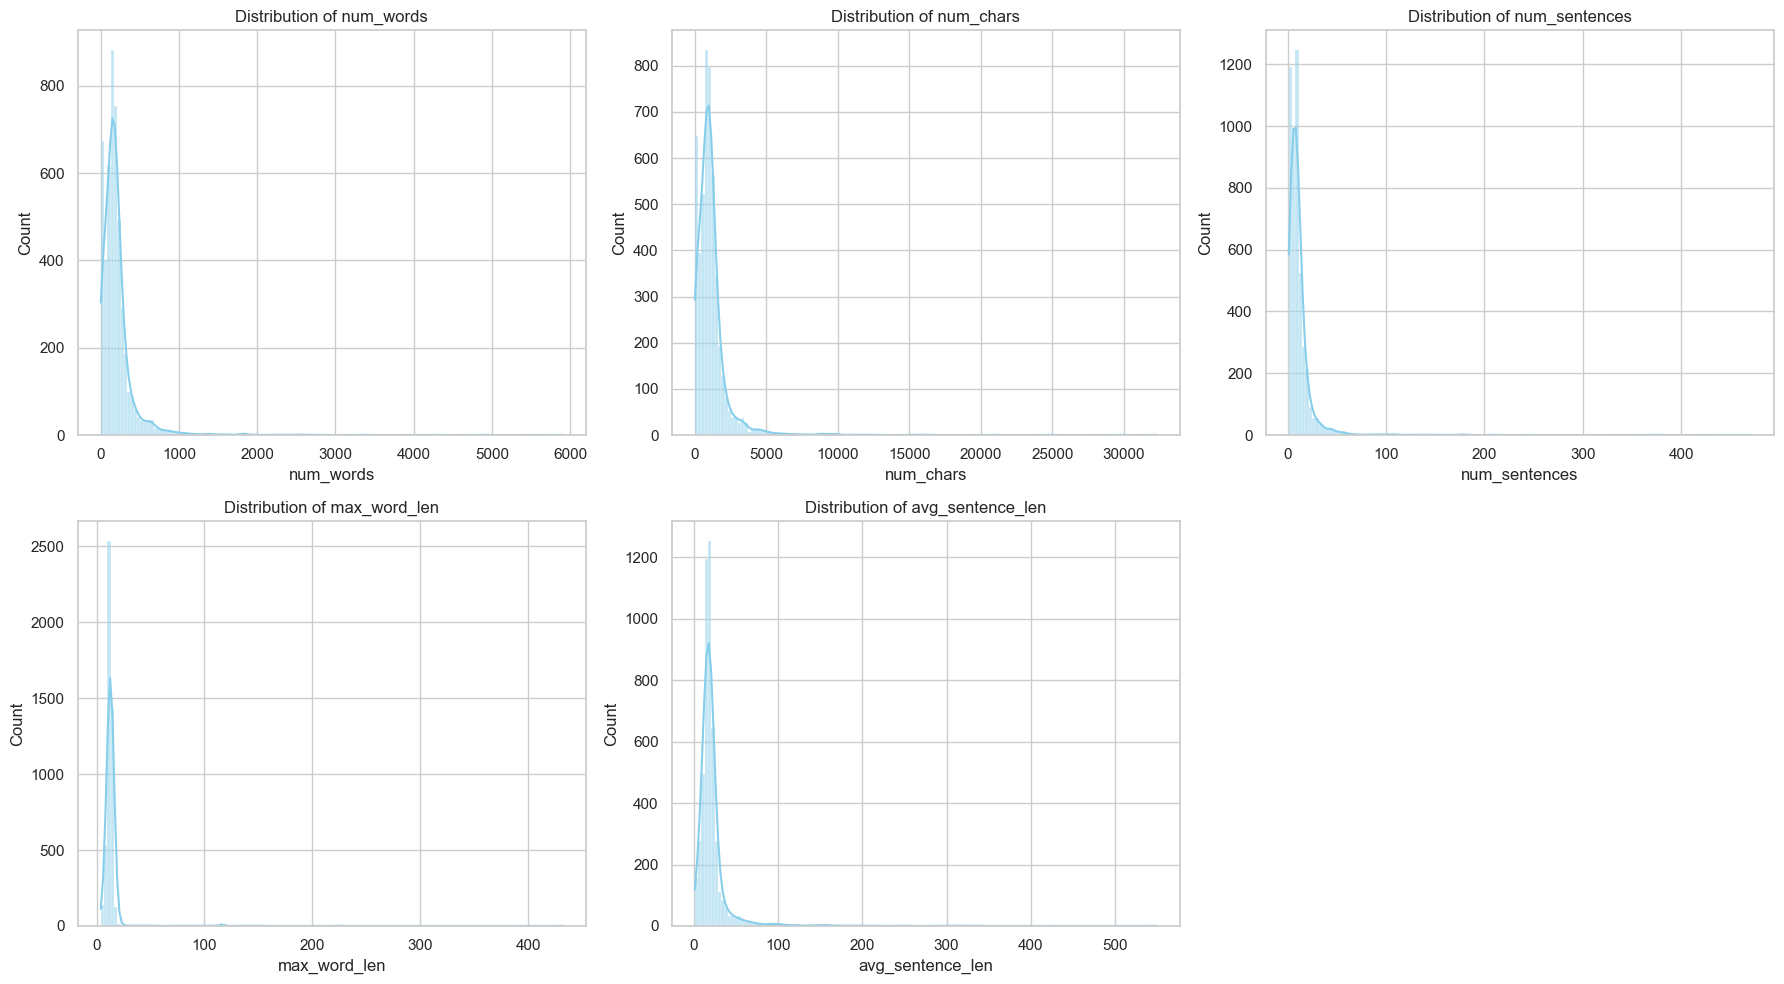

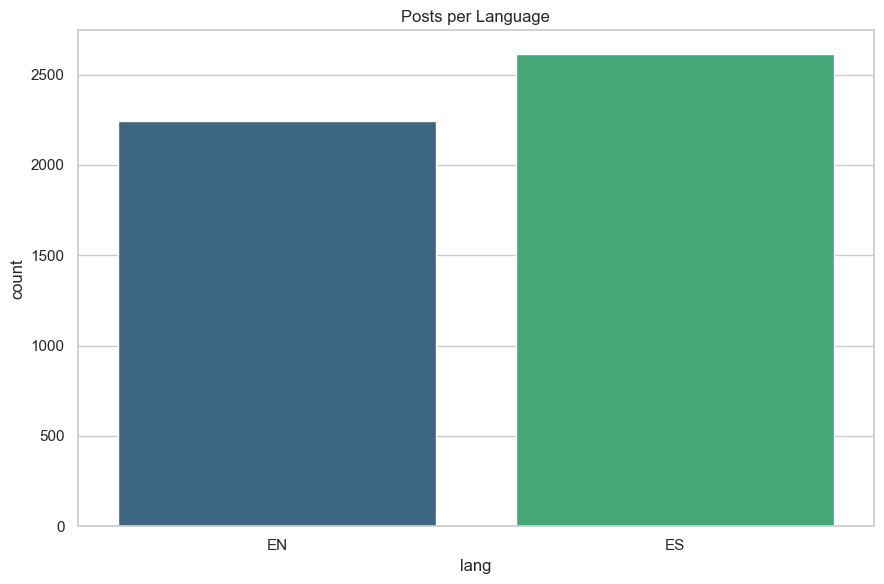

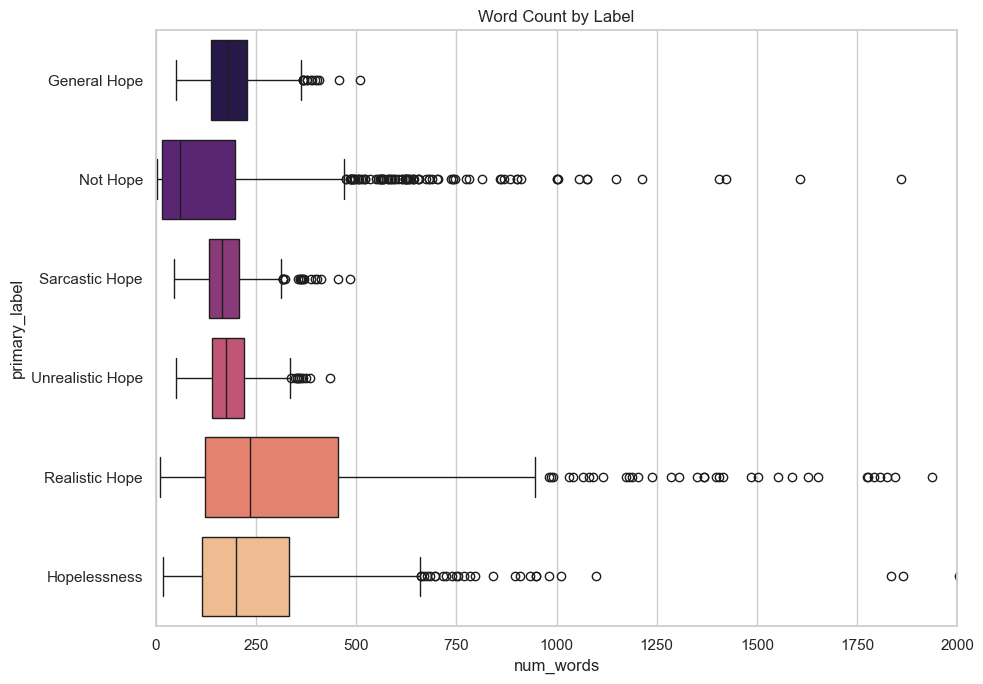

In [4]:
# 1. Length metrics distribution (as in eda.py)
metrics = ['num_words', 'num_chars', 'num_sentences', 'max_word_len', 'avg_sentence_len']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    sns.histplot(data=df_metrics, x=metric, kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {metric}')

if len(metrics) < len(axes):
    for j in range(len(metrics), len(axes)):
        fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()

# 2. Label and language analysis (separate figures)
plt.figure(figsize=(9, 6))
sns.countplot(data=df, x='lang', hue='lang', palette='viridis', legend=False)
plt.title('Posts per Language')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 7))
sns.boxplot(data=df_metrics, y='primary_label', x='num_words', hue='primary_label', palette='magma', legend=False)
plt.xlim(0, 2000)
plt.title('Word Count by Label')
plt.tight_layout()
plt.show()

## 4. Análisis Lingüístico (N-Grams por Idioma)
Exploramos los trigramas más comunes para cada idioma.

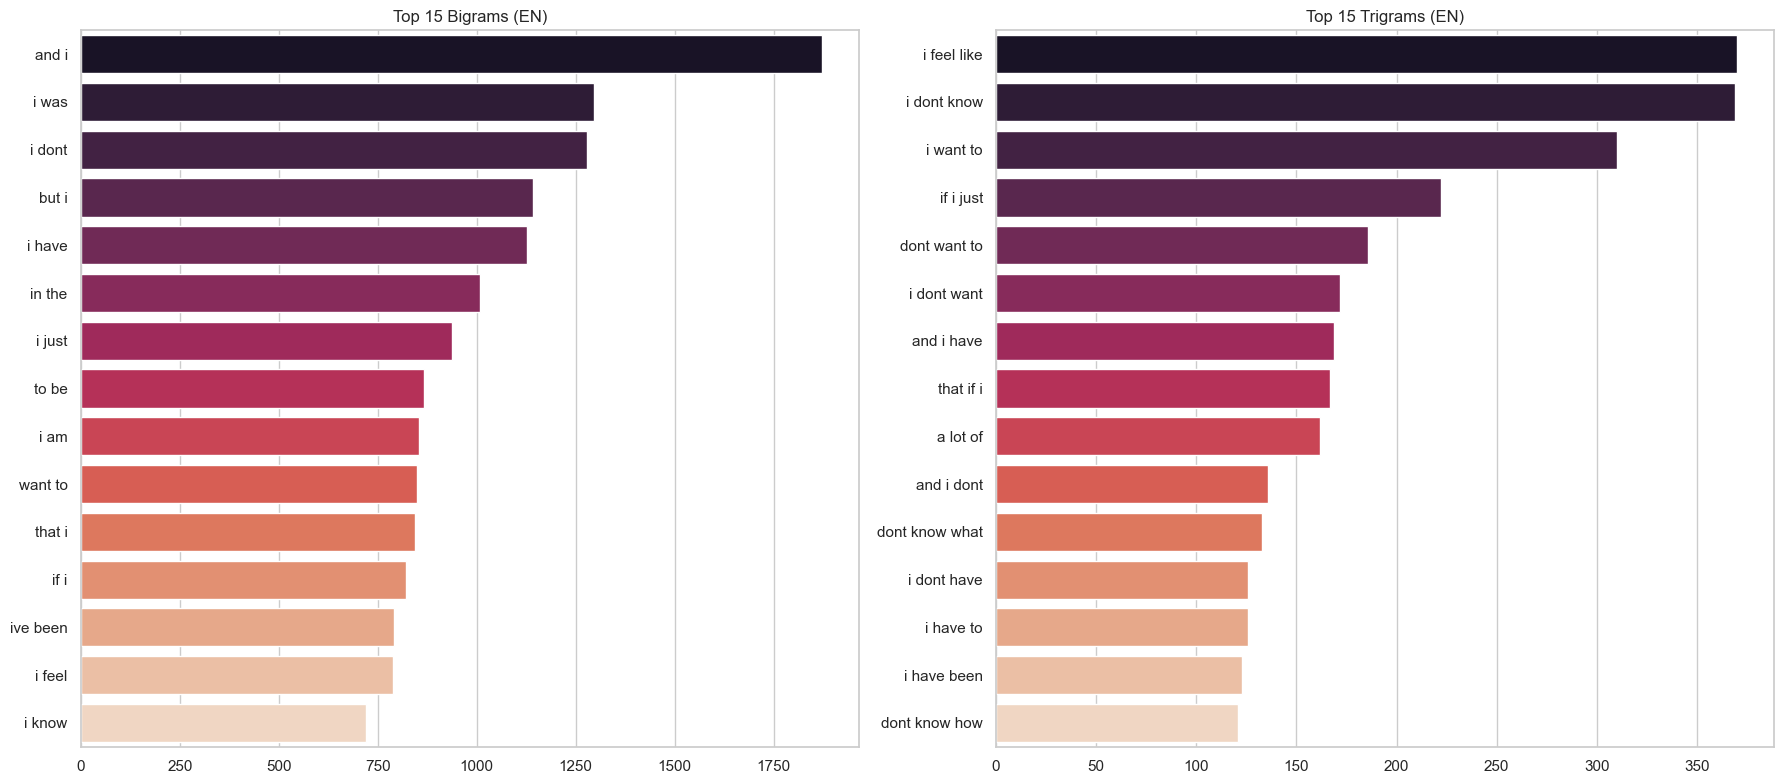

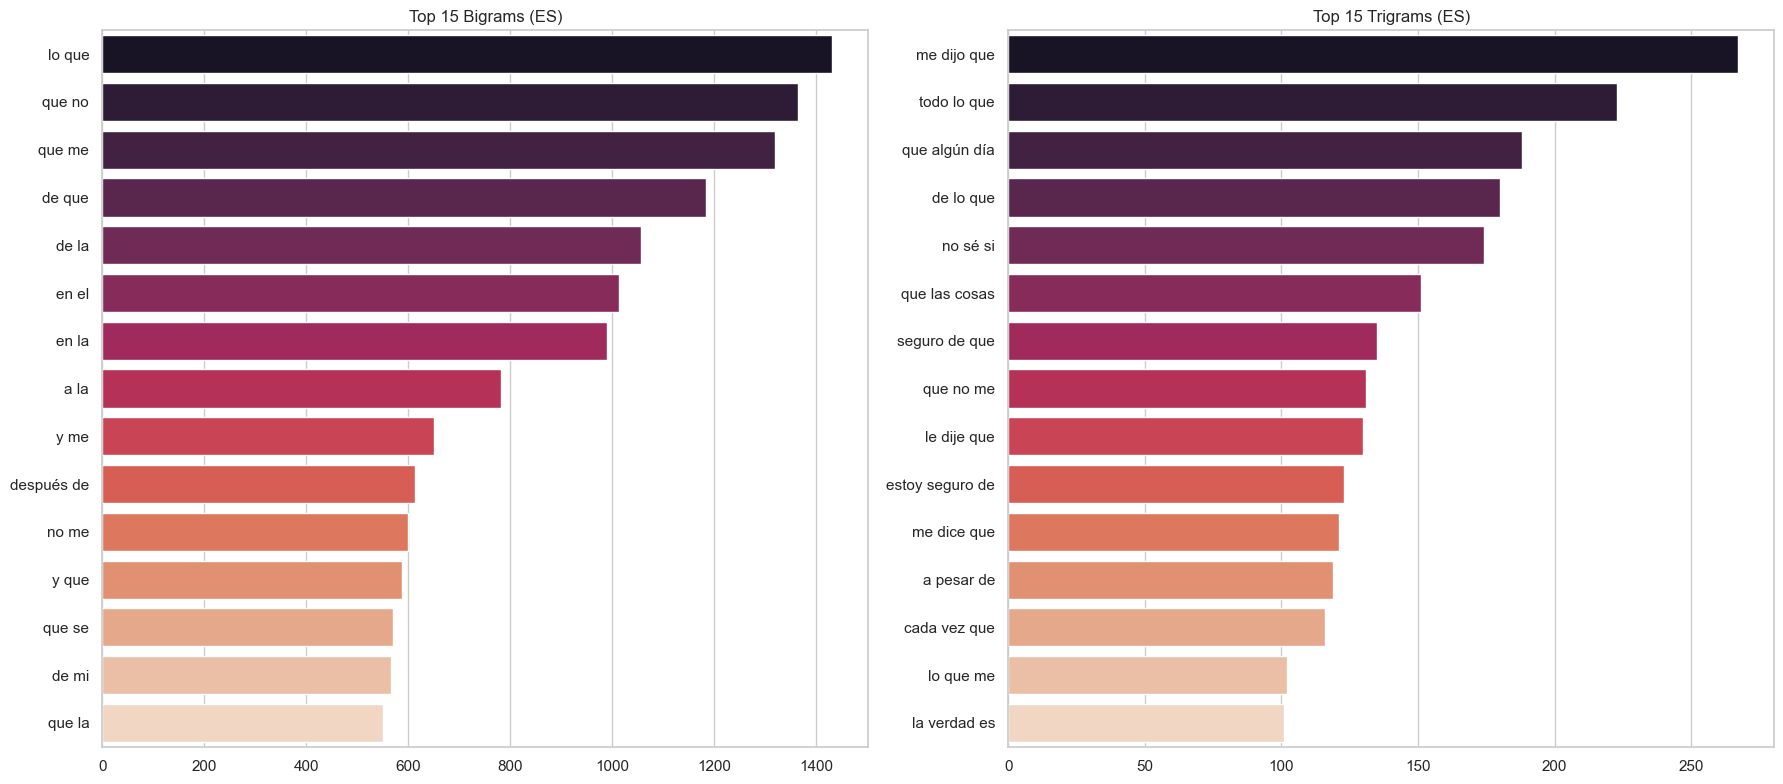

In [5]:
# 3. N-Grams por Idioma (Bigramas y Trigramas como en eda.py)
for lang in df['lang'].unique():
    lang_text = " ".join(df[df['lang'] == lang]['source_text'])
    if not lang_text.strip(): continue
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    for i, n in enumerate([2, 3]):
        ngrams = Counter(get_ngrams(lang_text, n)).most_common(15)
        if not ngrams: continue
        
        words, counts = zip(*ngrams)
        sns.barplot(x=list(counts), y=list(words), ax=axes[i], hue=list(words), palette='rocket', legend=False)
        axes[i].set_title(f'Top 15 {"Bigrams" if n==2 else "Trigrams"} ({lang})')
    
    plt.tight_layout()
    plt.show()